In [ ]:
import pandas as pd
df_mpra = pd.read_csv('../../mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv' , index_col=0)
df_mpra = df_mpra.drop_duplicates(subset='enhancer_id',keep='first')
df_500 = df_mpra

def pad_sequence(seq):
    if len(seq) < 500:
        left = (500 - len(seq))//2 * 'N'
        right =(500 - len(seq) - len(left)) * 'N'
        return left + seq + right
    else:
        return seq

# Apply the function to the 'full_seq' column
df_500['padded_seq'] = df_500['enhancer_seq'].apply(pad_sequence)
# Function to save the DataFrame as a FASTA file
def save_as_fasta(df, file_name):
    with open(file_name, 'w') as f:
        for index, row in df.iterrows():
            f.write(f">{row['enhancer_id']}\n")
            f.write(f"{row['padded_seq']}\n")

save_as_fasta(df_500, '20241001_MPRA_500bp_SNPandControl_Ns_227bpenhancers.fasta')
df_500 = df_500.reset_index()
df_500.to_csv("20241001_MPRA_500bp_SNPandControl_Ns_227bpenhancers.csv")

In [ ]:
import numpy as np
import pandas as pd
import logomaker

# Load the .npz file containing DeepSHAP scores
npz_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/THP1_LPSIFNG_Calvin_SHAP/attributions_from_shap.npz' 
seq_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/THP1_LPSIFNG_Calvin_SHAP/onehot_encoded_sequences.npz' 
seq_data  = np.load(seq_file_path)
shap_data = np.load(npz_file_path)
shap_scores_raw = np.array(shap_data['arr_0'])
seq_data_raw = np.array(seq_data['arr_0'])
# Squeeze the array to remove unnecessary dimensions (e.g., (1, 4, 500) -> (4, 500))

shap_scores_squeezed = np.squeeze(shap_scores_raw * seq_data_raw)
shap_scores_squeezed.shape
shap_scores_major = shap_scores_squeezed[:855, :,:] 
shap_scores_minor = shap_scores_squeezed[855:, :,:] 
shap_scores_diff = shap_scores_major-shap_scores_minor

import numpy as np
import pandas as pd
import logomaker
# Load the .npz file containing DeepSHAP scores
npz_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/THP1_LPSIFNG_Calvin_SHAP/attributions_from_shap.npz' 
seq_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/THP1_LPSIFNG_Calvin_SHAP/onehot_encoded_sequences.npz' 
seq_data  = np.load(seq_file_path)
shap_data = np.load(npz_file_path)
shap_scores_raw = np.array(shap_data['arr_0'])
seq_data_raw = np.array(seq_data['arr_0'])
# Squeeze the array to remove unnecessary dimensions (e.g., (1, 4, 500) -> (4, 500))
shap_scores_squeezed = np.squeeze(shap_scores_raw * seq_data_raw)
shap_scores_squeezed.shape
shap_scores_major = shap_scores_squeezed[:855, :,:] 
shap_scores_minor = shap_scores_squeezed[855:, :,:] 
shap_scores_diff2 = shap_scores_major-shap_scores_minor

In [2]:
import numpy as np
import pandas as pd
import logomaker
def split_shap(shap_scores_squeezed,distance =0):
    if distance !=0:
        left = shap_scores_squeezed[:, :, (250-distance):250]
        snp = shap_scores_squeezed[:, :, 250]
        right = shap_scores_squeezed[:, :, 251:(251+distance)]
        return left,snp,right
    else:
        snp = shap_scores_squeezed[:, :, 250]
        return None,snp,None


In [ ]:
import numpy as np
import pandas as pd
import logomaker
distance = 0
def split_shap(shap_scores_squeezed,distance =0):
    if distance !=0:
        left = shap_scores_squeezed[:, :, (250-distance):250]
        snp = shap_scores_squeezed[:, :, 250]
        right = shap_scores_squeezed[:, :, 251:(251+distance)]
        return left,snp,right
    else:
        snp = shap_scores_squeezed[:, :, 250]
        return None,snp,None
# Load the .npz file containing DeepSHAP scores
npz_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/WTC11_resting-model-best_SHAP/attributions_from_shap.npz' 
seq_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/WTC11_resting-model-best_SHAP/onehot_encoded_sequences.npz' 
seq_data  = np.load(seq_file_path)
shap_data = np.load(npz_file_path)
shap_scores_raw = np.array(shap_data['arr_0'])
seq_data_raw = np.array(seq_data['arr_0'])
# Squeeze the array to remove unnecessary dimensions (e.g., (1, 4, 500) -> (4, 500))
shap_scores_squeezed = np.squeeze(shap_scores_raw)
shap_scores_squeezed.shape
shap_scores_major = shap_scores_squeezed[:855, :,:]
shap_scores_minor = shap_scores_squeezed[855:, :,:]

left_major,snp_major,right_major = split_shap(shap_scores_major,distance =distance)
left_minor,snp_minor,right_minor = split_shap(shap_scores_minor,distance =distance)
if left_major is not None:
    left_difference = np.sum((left_major-left_minor),axis=1)
    right_difference = np.sum((right_major-right_minor),axis=1)
    snp_difference = (np.sum(snp_major,axis=1)-np.sum(snp_minor,axis=1)).reshape(855, 1)
    shap_scores_diff = np.concatenate((left_difference, snp_difference, right_difference), axis=1)
else:
    snp_difference = (np.sum(snp_major,axis=1)-np.sum(snp_minor,axis=1)).reshape(855, 1)
    shap_scores_diff = snp_difference

import numpy as np
import pandas as pd
import logomaker
# Load the .npz file containing DeepSHAP scores
npz_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/WTC11_resting-model-best_SHAP/attributions_from_shap.npz' 
seq_file_path = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/WTC11_resting-model-best_SHAP/onehot_encoded_sequences.npz' 
seq_data  = np.load(seq_file_path)
shap_data = np.load(npz_file_path)
shap_scores_raw = np.array(shap_data['arr_0'])
seq_data_raw = np.array(seq_data['arr_0'])
# Squeeze the array to remove unnecessary dimensions (e.g., (1, 4, 500) -> (4, 500))
shap_scores_squeezed = np.squeeze(shap_scores_raw)
shap_scores_squeezed.shape
shap_scores_major = shap_scores_squeezed[:855, :,:]
shap_scores_minor = shap_scores_squeezed[855:, :,:]

left_major,snp_major,right_major = split_shap(shap_scores_major,distance =distance)
left_minor,snp_minor,right_minor = split_shap(shap_scores_minor,distance =distance)
if left_major is not None:
    left_difference = np.sum((left_major-left_minor),axis=1)
    right_difference = np.sum((right_major-right_minor),axis=1)
    snp_difference = (np.sum(snp_major,axis=1)-np.sum(snp_minor,axis=1)).reshape(855, 1)
    shap_scores_diff2 = np.concatenate((left_difference, snp_difference, right_difference), axis=1)
else:
    snp_difference = (np.sum(snp_major,axis=1)-np.sum(snp_minor,axis=1)).reshape(855, 1)
    shap_scores_diff2 = snp_difference
sliced_array = shap_scores_diff/(distance*2+1) # Shape (855, 4, 25)
sliced_array2 = shap_scores_diff2/(distance*2+1) # Shape (855, 4, 25)

summed_values = np.sum(np.abs(sliced_array), axis=(1))
summed_values2 = np.sum(np.abs(sliced_array2), axis=(1))
min_nonzero = np.min(summed_values2[summed_values2 > 0])  # Find smallest nonzero value
summed_values2[summed_values2 == 0] = min_nonzero  # Replace all zeros


[LOGNORMAL FIT] shape=2.2278, loc=0.0000, scale=0.0439
Total data points: 855
[LOGNORMAL FIT] shape=2.3860, loc=0.0000, scale=0.0427
Total data points: 855
[LOGNORMAL FIT] shape=2.3694, loc=0.0000, scale=0.0203
Total data points: 855
[LOGNORMAL FIT] shape=2.1445, loc=0.0000, scale=0.0667
Total data points: 855
[LOGNORMAL FIT] shape=2.6758, loc=0.0000, scale=0.0331
Total data points: 855
[LOGNORMAL FIT] shape=2.3930, loc=0.0000, scale=0.0580
Total data points: 855
[LOGNORMAL FIT] shape=2.4502, loc=0.0000, scale=0.0576
Total data points: 855
[LOGNORMAL FIT] shape=2.2183, loc=0.0000, scale=0.0616
Total data points: 855
[LOGNORMAL FIT] shape=2.4455, loc=0.0000, scale=0.0474
Total data points: 855
[LOGNORMAL FIT] shape=2.3168, loc=0.0000, scale=0.0519
Total data points: 855
[LOGNORMAL FIT] shape=2.4494, loc=0.0000, scale=0.0301
Total data points: 855
[LOGNORMAL FIT] shape=3.8225, loc=0.0000, scale=0.0650
Total data points: 855
[LOGNORMAL FIT] shape=2.3973, loc=0.0000, scale=0.0360
Total dat

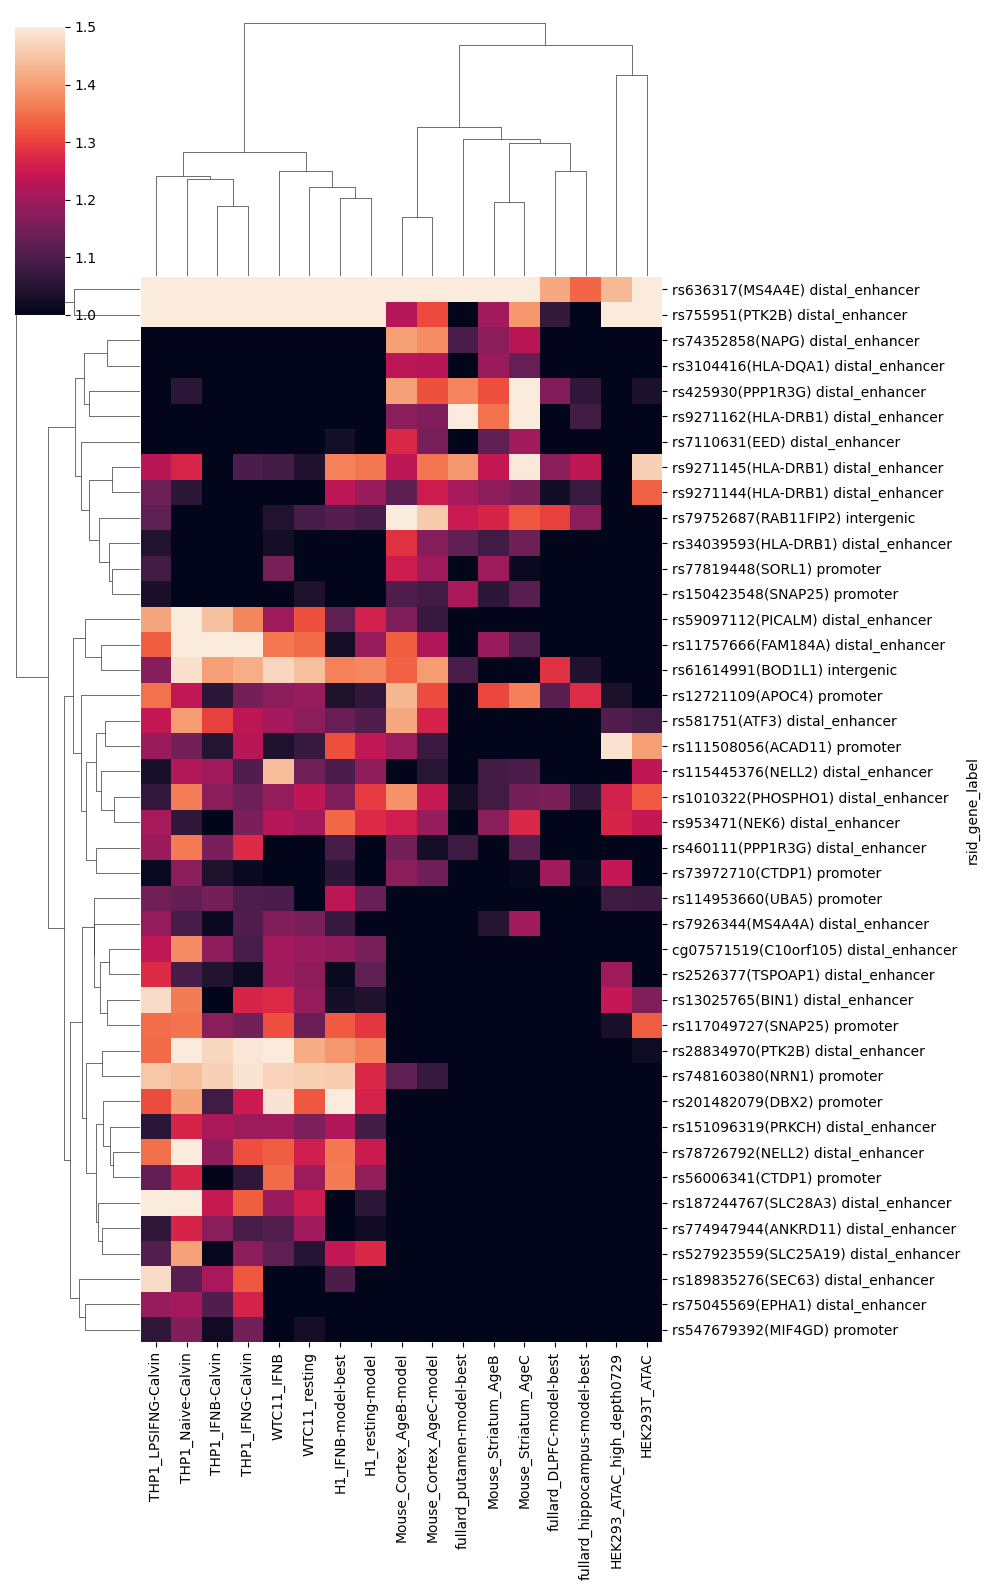

In [2]:
import pandas as pd
import numpy as np
import numpy as np
from scipy.stats import lognorm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
def compute_atac_pvalues_no_fdr(
    df_pos_diff: np.ndarray,
    df_neg_diff: np.ndarray,
    index_csv_path: str
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs using new data inputs.

    Parameters
    ----------
    df_pos_diff : np.ndarray
        Array of SHAP effect differences from the positive set.
    df_neg_diff : np.ndarray
        Array of SHAP effect differences from the negative set (null distribution).
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    # Ensure input arrays have the correct length
    N = 855
    if len(df_pos_diff) != N or len(df_neg_diff) != N:
        raise ValueError(f"Expected {N} values for both positive and negative datasets, "
                         f"but got {len(df_pos_diff)} and {len(df_neg_diff)}.")

    # Compute absolute SHAP effect sizes
    summed_values = np.abs(df_pos_diff)
    summed_values_null = np.abs(df_neg_diff)

    # ----------------------------------------
    # Handle Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result

folders = [
    'H1_IFNB-model-best',
    'H1_resting-model',
    'HEK293_ATAC_high_depth0729',
    'HEK293T_ATAC',
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting',
    'fullard_DLPFC-model-best',
    'fullard_hippocampus-model-best',
    'fullard_putamen-model-best',
#    "astrocyte_GSE188398-model-best",
#    "oligodendrocyte_GSE143666-model-best"

]

pairs = []
for f in folders:
    pairs.append((
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()

for (file1, file2, model) in pairs:
    # Load and process the positive dataset
    df_pos = pd.read_csv(file1, header=None)
    df_pos = df_pos.groupby(df_pos.index // 2).mean()
    df_pos_diff = np.array(df_pos.loc[:854][0]) - np.array(df_pos.loc[855:][0])

    # Load and process the negative dataset
    df_neg = pd.read_csv(file2, header=None)
    df_neg = df_neg.groupby(df_neg.index // 2).mean()
    df_neg_diff = np.array(df_neg.loc[:854][0]) - np.array(df_neg.loc[855:][0])

    # Compute SHAP p-values and effect sizes
    df_result = compute_atac_pvalues_no_fdr(
        df_pos_diff=df_pos_diff,
        df_neg_diff=df_neg_diff,
        index_csv_path=index_csv_path
    )

    # Store results
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']

df_index = pd.read_csv('../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
p_threshold = 0.101
'''
# Select columns that contain 'THP1'
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
thp1_columns.remove('THP1_monocyte0729')
# Find rows where all selected columns have values <= 0.05
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]
mask = (all_p_values_unique['THP1_monocyte0729'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)

thp1_mono_rows = all_p_values_unique[mask]

# Select columns that contain 'THP1'
wtc11_columns = [col for col in all_p_values_unique.columns if 'WTC11' in col]
# Find rows where all selected columns have values <= 0.05
wtc11_rows = all_p_values_unique[(all_p_values_unique[wtc11_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_cortex_columns = [col for col in all_p_values_unique.columns if 'Mouse_Cortex' in col]
# Find rows where all selected columns have values <= 0.05
mouse_cortex_rows = all_p_values_unique[(all_p_values_unique[mouse_cortex_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_striatum_columns = [col for col in all_p_values_unique.columns if 'Mouse_Striatum' in col]
# Find rows where all selected columns have values <= 0.05
mouse_striatum_rows = all_p_values_unique[(all_p_values_unique[mouse_striatum_columns] <= p_threshold).all(axis=1)]

all_rows = all_p_values_unique[(all_p_values_unique<= p_threshold).all(axis=1)]

df_visualize = pd.concat([all_rows,thp1_rows,thp1_mono_rows,wtc11_rows,mouse_striatum_rows,mouse_striatum_rows] ).drop_duplicates().drop(['H1_IFNB-model', 'H1_resting-model',],axis=1)
'''
######################################################################

# Select THP1-related columns
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
if 'THP1_monocyte0729' in thp1_columns:
    thp1_columns.remove('THP1_monocyte0729')

# Find rows where all THP1-related columns meet threshold
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]

# Find rows where THP1_monocyte0729-model-best_SHAP meets the threshold, but all other THP1 columns don't
mask = (all_p_values_unique['THP1_monocyte0729'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)
thp1_mono_rows = all_p_values_unique[mask]

no_hek_columns = [col for col in all_p_values_unique.columns if "HEK293" not in col]
hek_columns = [col for col in all_p_values_unique.columns if "HEK293" in col]
mask2 = ( 
    (all_p_values_unique[hek_columns] > p_threshold).all(axis=1) & 
    (all_p_values_unique[no_hek_columns] <= p_threshold).all(axis=1)  # At least one HEK293 column > p_threshold
)
nohek_rows = all_p_values_unique[mask2]

# Function to find significant rows based on column pattern
def filter_rows_by_keyword(df, keyword, threshold):
    cols = [col for col in df.columns if keyword in col]
    if cols:
        return df[(df[cols] <= threshold).all(axis=1)]
    return pd.DataFrame(columns=df.columns)  # Return empty DataFrame if no matching columns

mouse_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse', p_threshold)

# Apply function to find significant rows
wtc11_rows = filter_rows_by_keyword(all_p_values_unique, 'WTC11', p_threshold)
mouse_cortex_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Cortex', p_threshold)
mouse_striatum_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Striatum', p_threshold)

# Find rows where all columns meet threshold
all_rows = all_p_values_unique[(all_p_values_unique <= p_threshold).all(axis=1)]


# Define a function to sort rows based on the sum of their respective columns
def sort_rows_by_sum(df, keyword):
    cols = [col for col in df.columns if keyword in col] if keyword else df.columns.tolist()
    if cols:
        df = df.copy()
        df['sum_values'] = df[cols].sum(axis=1)
        df = df.sort_values(by='sum_values', ascending=True).drop(columns=['sum_values'])
    return df

# Sort each filtered DataFrame separately
all_rows_sorted = sort_rows_by_sum(all_rows, '')
thp1_rows_sorted = sort_rows_by_sum(thp1_rows, 'THP1')
thp1_mono_rows_sorted = sort_rows_by_sum(thp1_mono_rows, 'THP1_monocyte0729')
wtc11_rows_sorted = sort_rows_by_sum(wtc11_rows, 'WTC11')
mouse_cortex_rows_sorted = sort_rows_by_sum(mouse_cortex_rows, 'Mouse_Cortex')
mouse_striatum_rows_sorted = sort_rows_by_sum(mouse_striatum_rows, 'Mouse_Striatum')
mouse_rows_sorted = sort_rows_by_sum(mouse_rows, 'Mouse')
nohek_rows_sorted = sort_rows_by_sum(nohek_rows, 'HEK')

df_sorted_visualize = pd.concat([
    all_rows_sorted,thp1_rows_sorted,mouse_rows_sorted]).drop_duplicates()

# Drop unwanted columns safely
columns_to_drop = ['THP1_monocyte0729']
df_sorted_visualize = df_sorted_visualize.drop(columns=[col for col in columns_to_drop if col in df_sorted_visualize.columns], errors='ignore')
g = sns.clustermap(
    -np.log10(df_sorted_visualize),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 16),col_cluster=True,row_cluster=True
)

all_p_values_atac = all_p_values.copy()


In [3]:
all_p_values_unique_prediction = all_p_values_unique.copy()
prediction_list = []
for i in all_p_values_unique.columns:
    prediction_list.append(i+"_Prediction")
all_p_values_unique_prediction.columns = prediction_list
row_prediction_index = df_sorted_visualize.index

[LOGNORMAL FIT] shape=2.2309, loc=0.0000, scale=0.0346
Total data points: 855
[LOGNORMAL FIT] shape=2.3384, loc=0.0000, scale=0.0332
Total data points: 855
[LOGNORMAL FIT] shape=2.2117, loc=0.0000, scale=0.0649
Total data points: 855
[LOGNORMAL FIT] shape=2.1534, loc=0.0000, scale=0.0606
Total data points: 855
[LOGNORMAL FIT] shape=2.3182, loc=0.0000, scale=0.0583
Total data points: 855
[LOGNORMAL FIT] shape=2.2306, loc=0.0000, scale=0.0584
Total data points: 855
[LOGNORMAL FIT] shape=2.2160, loc=0.0000, scale=0.0596
Total data points: 855
[LOGNORMAL FIT] shape=2.1206, loc=0.0000, scale=0.0259
Total data points: 855
[LOGNORMAL FIT] shape=2.2069, loc=0.0000, scale=0.0475
Total data points: 855
[LOGNORMAL FIT] shape=2.1509, loc=0.0000, scale=0.0827
Total data points: 855
[LOGNORMAL FIT] shape=2.2812, loc=0.0000, scale=0.0763
Total data points: 855
[LOGNORMAL FIT] shape=2.4642, loc=0.0000, scale=0.0411
Total data points: 855
[LOGNORMAL FIT] shape=2.1424, loc=0.0000, scale=0.0544
Total dat

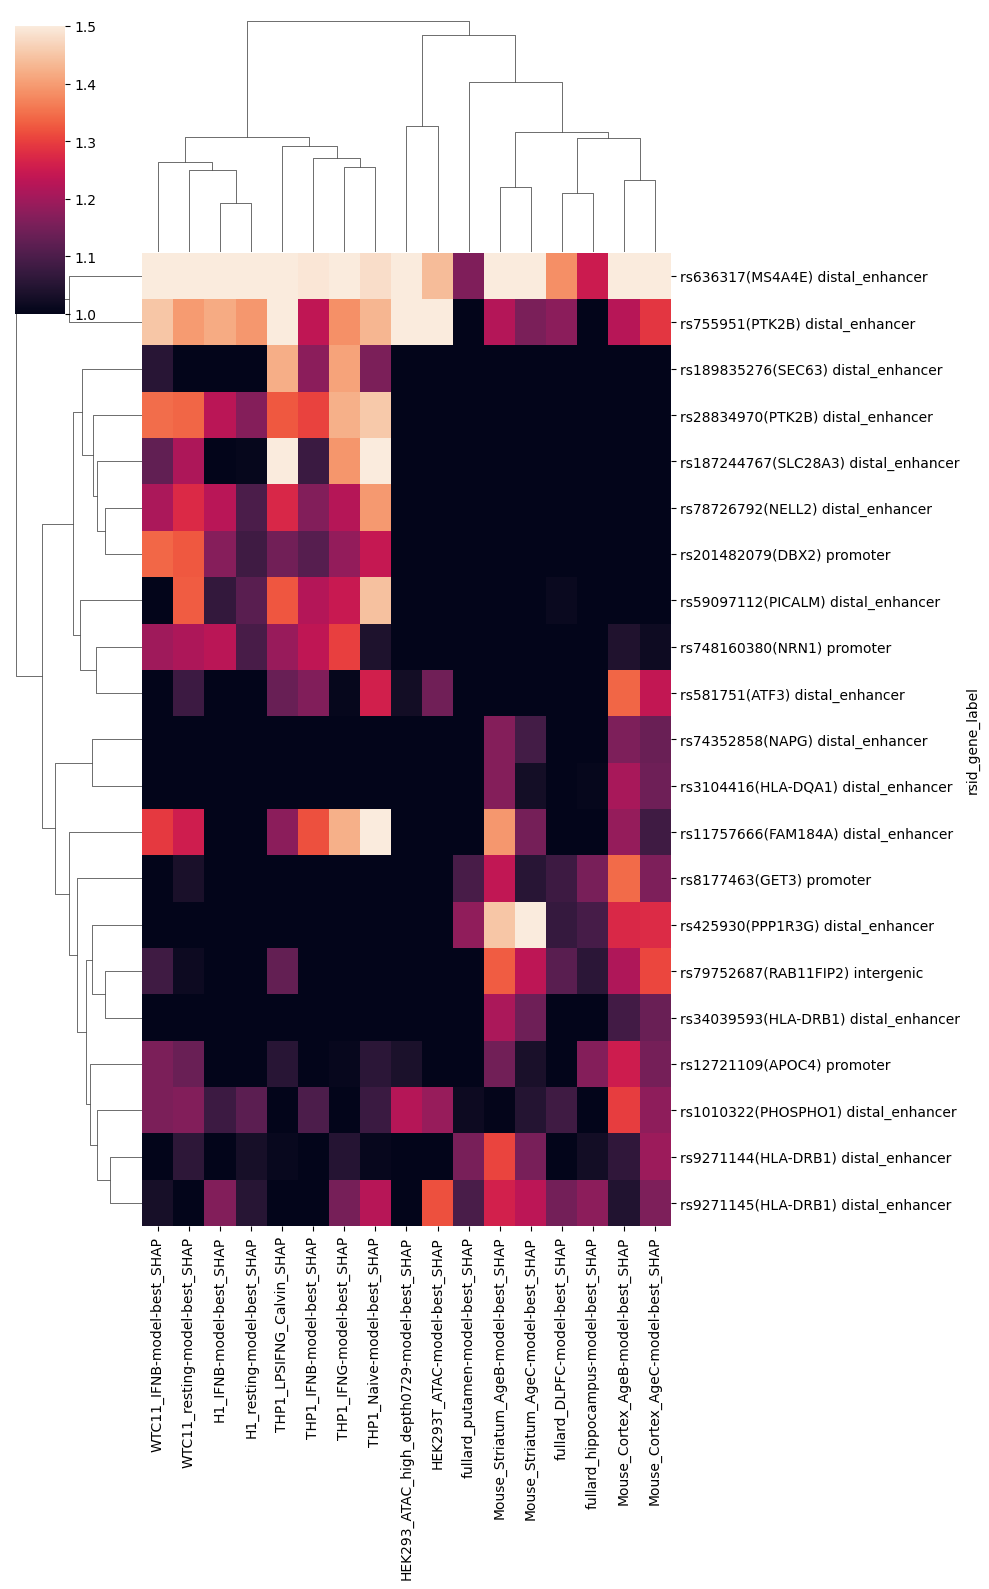

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm

def compute_shap_pvalues_no_fdr(
    npz_file_path_major_minor: str,
    npz_file_path_major_minor_null: str,
    index_csv_path: str,
    distance: int = 0
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs.

    Parameters
    ----------
    npz_file_path_major_minor : str
        Path to the first .npz file (major/minor).
    npz_file_path_major_minor_null : str
        Path to the second .npz file (major/minor) for the null distribution.
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.
    distance : int, optional
        Flanking distance around position 250 (default=0 => only position 250).

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    def split_shap(shap_scores_squeezed, distance=0):
        """Splits SHAP values into left, SNP, and right based on distance."""
        if distance != 0:
            left = shap_scores_squeezed[:, :, (250 - distance):250]
            snp = shap_scores_squeezed[:, :, 250]
            right = shap_scores_squeezed[:, :, 251:(251 + distance)]
            return left, snp, right
        else:
            snp = shap_scores_squeezed[:, :, 250]
            return None, snp, None

    # ----------------------------------------
    # 1. Load SHAP arrays
    # ----------------------------------------
    shap_data_1 = np.load(npz_file_path_major_minor)
    shap_data_2 = np.load(npz_file_path_major_minor_null)

    shap_scores_squeezed_1 = np.squeeze(shap_data_1['arr_0'])
    shap_scores_squeezed_2 = np.squeeze(shap_data_2['arr_0'])

    # Number of SNPs
    N = 855

    # Extract major/minor SHAP values
    shap_scores_major_1 = shap_scores_squeezed_1[:N, :, :]
    shap_scores_minor_1 = shap_scores_squeezed_1[N:, :, :]
    shap_scores_major_2 = shap_scores_squeezed_2[:N, :, :]
    shap_scores_minor_2 = shap_scores_squeezed_2[N:, :, :]

    # ----------------------------------------
    # 2. Compute SHAP Differences
    # ----------------------------------------
    left_major, snp_major, right_major = split_shap(shap_scores_major_1, distance)
    left_minor, snp_minor, right_minor = split_shap(shap_scores_minor_1, distance)

    left_major_null, snp_major_null, right_major_null = split_shap(shap_scores_major_2, distance)
    left_minor_null, snp_minor_null, right_minor_null = split_shap(shap_scores_minor_2, distance)

    if left_major is not None:
        left_diff = np.sum(left_major - left_minor, axis=1)
        right_diff = np.sum(right_major - right_minor, axis=1)
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = np.concatenate((left_diff, snp_diff, right_diff), axis=1)
        
        left_diff_null = np.sum(left_major_null - left_minor_null, axis=1)
        right_diff_null = np.sum(right_major_null - right_minor_null, axis=1)
        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = np.concatenate((left_diff_null, snp_diff_null, right_diff_null), axis=1)
    else:
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = snp_diff

        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = snp_diff_null

    # ----------------------------------------
    # 3. Normalize & Compute Summed Values
    # ----------------------------------------
    divisor = (distance * 2 + 1) if distance != 0 else 1
    sliced_array = shap_scores_diff / divisor
    sliced_array_null = shap_scores_diff_null / divisor

    summed_values = np.sum(np.abs(sliced_array), axis=1)
    summed_values_null = np.sum(np.abs(sliced_array_null), axis=1)

    # ----------------------------------------
    # 4. Replace Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # 5. Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # 6. Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # 7. Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result


folders = ['fullard_DLPFC-model-best_SHAP', 'fullard_hippocampus-model-best_SHAP','fullard_putamen-model-best_SHAP','H1_IFNB-model-best_SHAP',                     'THP1_IFNB-model-best_SHAP',
'H1_resting-model-best_SHAP',                  'THP1_IFNG-model-best_SHAP',
'HEK293_ATAC_high_depth0729-model-best_SHAP',  'THP1_LPSIFNG_Calvin_SHAP',
'HEK293T_ATAC-model-best_SHAP',                'THP1_monocyte0729-model-best_SHAP',
'Mouse_Cortex_AgeB-model-best_SHAP',           'THP1_Naive-model-best_SHAP',
'Mouse_Cortex_AgeC-model-best_SHAP',           'WTC11_IFNB-model-best_SHAP',
'Mouse_Striatum_AgeB-model-best_SHAP',         'WTC11_resting-model-best_SHAP',
'Mouse_Striatum_AgeC-model-best_SHAP',
]
pairs = []
for f in folders:
    pairs.append((
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/{f}/attributions_from_shap.npz',
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/{f}/attributions_from_shap.npz',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
for (file1, file2,model) in pairs:
    df_result = compute_shap_pvalues_no_fdr(
        npz_file_path_major_minor=file1,
        npz_file_path_major_minor_null=file2,
        index_csv_path=index_csv_path,
        distance=0  # or use something else
    )
    # you can store or save df_result
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']


df_index = pd.read_csv('../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
p_threshold = 0.101
'''
# Select columns that contain 'THP1'
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
thp1_columns.remove('THP1_monocyte0729-model-best_SHAP')
# Find rows where all selected columns have values <= 0.05
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]
mask = (all_p_values_unique['THP1_monocyte0729-model-best_SHAP'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)

thp1_mono_rows = all_p_values_unique[mask]

# Select columns that contain 'THP1'
wtc11_columns = [col for col in all_p_values_unique.columns if 'WTC11' in col]
# Find rows where all selected columns have values <= 0.05
wtc11_rows = all_p_values_unique[(all_p_values_unique[wtc11_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_cortex_columns = [col for col in all_p_values_unique.columns if 'Mouse_Cortex' in col]
# Find rows where all selected columns have values <= 0.05
mouse_cortex_rows = all_p_values_unique[(all_p_values_unique[mouse_cortex_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_striatum_columns = [col for col in all_p_values_unique.columns if 'Mouse_Striatum' in col]
# Find rows where all selected columns have values <= 0.05
mouse_striatum_rows = all_p_values_unique[(all_p_values_unique[mouse_striatum_columns] <= p_threshold).all(axis=1)]

all_rows = all_p_values_unique[(all_p_values_unique<= p_threshold).all(axis=1)]

df_visualize = pd.concat([all_rows,thp1_rows,thp1_mono_rows,wtc11_rows,mouse_striatum_rows,mouse_striatum_rows] ).drop_duplicates().drop(['H1_IFNB-model-best_SHAP', 'H1_resting-model-best_SHAP',],axis=1)
'''
####################################################################################################################################
import numpy as np
import pandas as pd
import seaborn as sns

# 1) Identify relevant columns
thp1_columns = [
    c for c in all_p_values_unique.columns
    if 'THP1' in c and c != 'THP1_monocyte0729-model-best_SHAP'
]
hek_columns = [c for c in all_p_values_unique.columns if 'HEK293' in c]
no_hek_columns = [c for c in all_p_values_unique.columns if 'HEK293' not in c]

# 2) Filter DataFrames
thp1_rows = all_p_values_unique[
    (all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)
]

thp1_mono_mask = (
    (all_p_values_unique['THP1_monocyte0729-model-best_SHAP'] <= p_threshold) &
    (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)
)
thp1_mono_rows = all_p_values_unique[thp1_mono_mask]

nohek_mask = (
    (all_p_values_unique[hek_columns] > p_threshold).all(axis=1) &
    (all_p_values_unique[no_hek_columns] <= p_threshold).all(axis=1)
)
nohek_rows = all_p_values_unique[nohek_mask]

# 3) Helper function to filter rows by keyword
def filter_rows_by_keyword(df, keyword, threshold):
    """
    Return rows for which all columns containing `keyword`
    are <= threshold. Returns an empty DataFrame if none found.
    """
    cols = df.filter(like=keyword)
    if cols.empty:
        return df.iloc[0:0]  # empty DataFrame with same columns
    return df[(cols <= threshold).all(axis=1)]

mouse_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse', p_threshold)
wtc11_rows = filter_rows_by_keyword(all_p_values_unique, 'WTC11', p_threshold)
mouse_cortex_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Cortex', p_threshold)
mouse_striatum_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Striatum', p_threshold)

# 4) Find rows meeting threshold in all columns
all_rows = all_p_values_unique[
    (all_p_values_unique <= p_threshold).all(axis=1)
]

# 5) Sorting function
def sort_rows_by_sum(df, keyword=None):
    """
    Sort rows by the sum of columns containing `keyword`.
    If `keyword=None`, sort by the sum across all columns.
    """
    # If keyword is given, filter columns by that keyword; else use all columns
    cols = df.filter(like=keyword).columns if keyword else df.columns
    if cols.empty:
        return df

    out = df.copy()
    out['sum_values'] = out[cols].sum(axis=1)
    out = out.sort_values('sum_values').drop(columns='sum_values')
    return out

# 6) Sort each subset
all_rows_sorted = sort_rows_by_sum(all_rows)
thp1_rows_sorted = sort_rows_by_sum(thp1_rows, 'THP1')
thp1_mono_rows_sorted = sort_rows_by_sum(thp1_mono_rows, 'THP1_monocyte0729')
nohek_rows_sorted = sort_rows_by_sum(nohek_rows, 'HEK')
wtc11_rows_sorted = sort_rows_by_sum(wtc11_rows, 'WTC11')
mouse_rows_sorted = sort_rows_by_sum(mouse_rows, 'Mouse')
mouse_cortex_rows_sorted = sort_rows_by_sum(mouse_cortex_rows, 'Mouse_Cortex')
mouse_striatum_rows_sorted = sort_rows_by_sum(mouse_striatum_rows, 'Mouse_Striatum')

# 7) Concatenate subsets for visualization
df_sorted_visualize = pd.concat([
    all_rows_sorted,
    thp1_rows_sorted,
    mouse_rows_sorted,
]).drop_duplicates()

# 8) Drop undesired columns if they exist
columns_to_drop = [
 #   'H1_IFNB-model-best_SHAP',
 #   'H1_resting-model-best_SHAP',
    'THP1_monocyte0729-model-best_SHAP'
]
df_sorted_visualize = df_sorted_visualize.drop(
    columns=[c for c in columns_to_drop if c in df_sorted_visualize],
    errors='ignore'
)

# 9) Create cluster map
g = sns.clustermap(
    -np.log10(df_sorted_visualize),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 16),
    col_cluster=True,
    row_cluster=True
)

all_p_values_shap = all_p_values.copy()

In [5]:
all_p_values_unique_shap = all_p_values_unique.copy()
prediction_list = []
for i in all_p_values_unique.columns:
    prediction_list.append(i+"_SHAP")
all_p_values_unique_shap.columns = prediction_list
row_shap_index = df_sorted_visualize.index

In [6]:
all_p_values_unique_shap.columns

Index(['fullard_DLPFC-model-best_SHAP_SHAP',
       'fullard_hippocampus-model-best_SHAP_SHAP',
       'fullard_putamen-model-best_SHAP_SHAP', 'H1_IFNB-model-best_SHAP_SHAP',
       'THP1_IFNB-model-best_SHAP_SHAP', 'H1_resting-model-best_SHAP_SHAP',
       'THP1_IFNG-model-best_SHAP_SHAP',
       'HEK293_ATAC_high_depth0729-model-best_SHAP_SHAP',
       'THP1_LPSIFNG_Calvin_SHAP_SHAP', 'HEK293T_ATAC-model-best_SHAP_SHAP',
       'THP1_monocyte0729-model-best_SHAP_SHAP',
       'Mouse_Cortex_AgeB-model-best_SHAP_SHAP',
       'THP1_Naive-model-best_SHAP_SHAP',
       'Mouse_Cortex_AgeC-model-best_SHAP_SHAP',
       'WTC11_IFNB-model-best_SHAP_SHAP',
       'Mouse_Striatum_AgeB-model-best_SHAP_SHAP',
       'WTC11_resting-model-best_SHAP_SHAP',
       'Mouse_Striatum_AgeC-model-best_SHAP_SHAP'],
      dtype='object')

Saved: index_table_from_figure_order_full_labels.csv
Rows in target order found in data: 43
Rows from figure order missing in data: 0
Saved heatmap:
  atac_shap_snp_clustering_REVISION.pdf
  atac_shap_snp_clustering_REVISION.svg


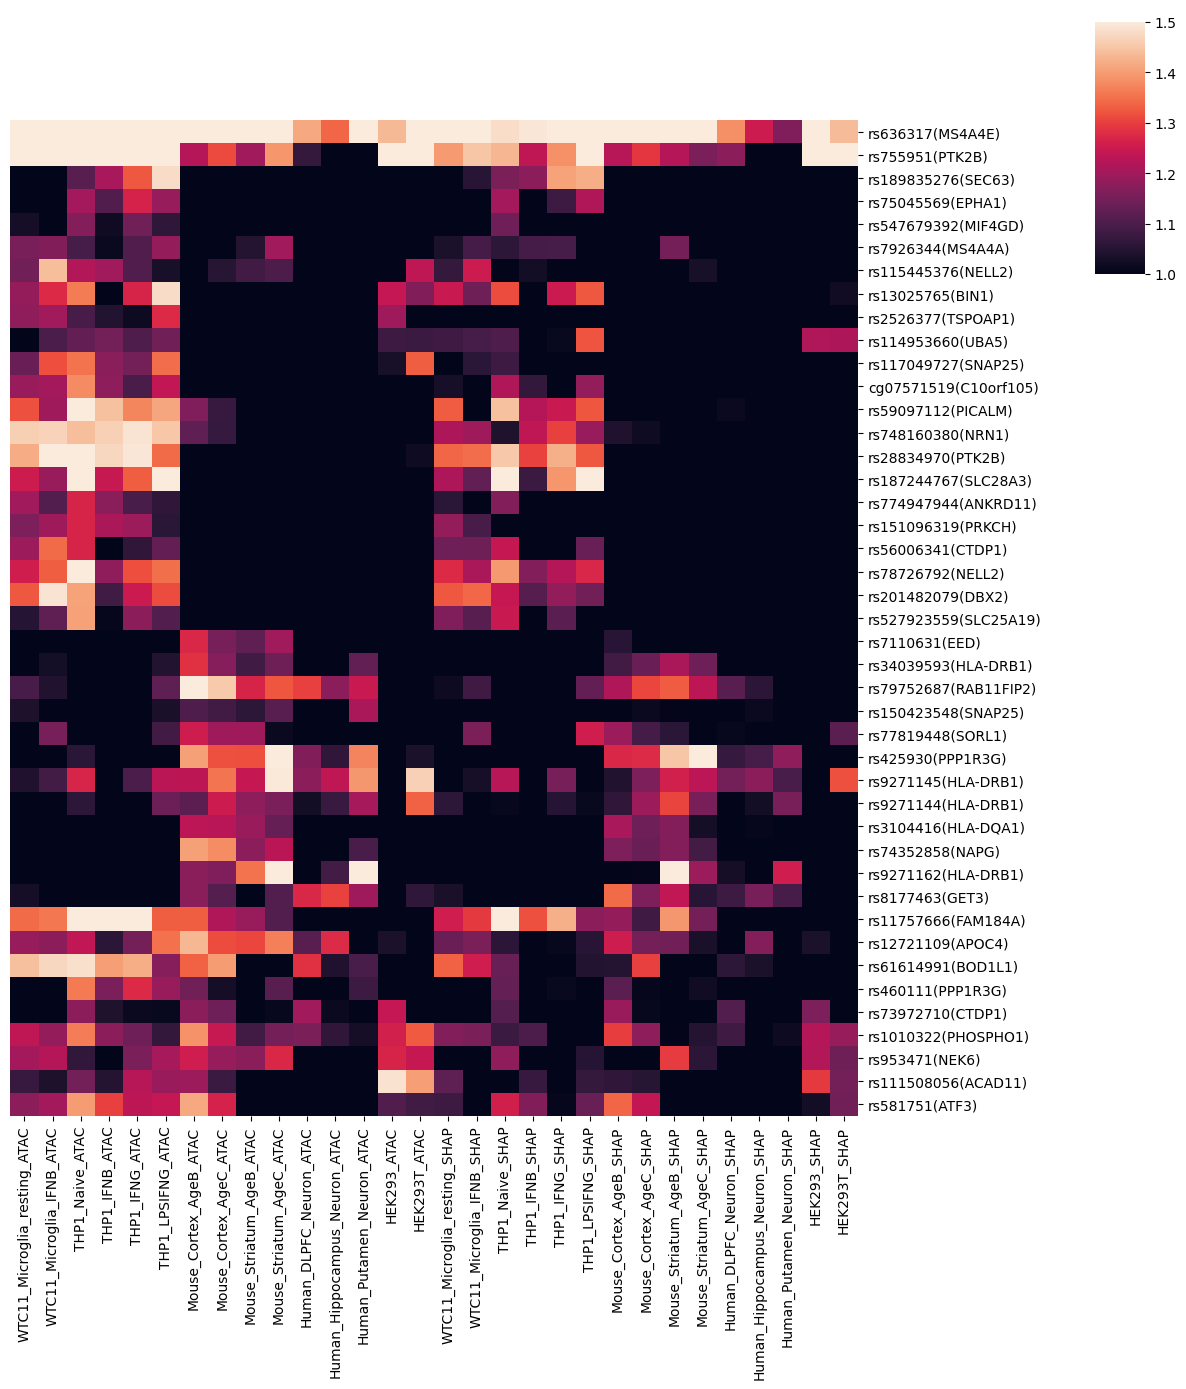

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================================================
# Make PDF/SVG text Illustrator-friendly
# =========================================================
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# =========================================================
# 0) Input columns
# =========================================================
select_columns_prediction = [
    'WTC11_resting_Prediction',
    'WTC11_IFNB_Prediction',
    'THP1_Naive-Calvin_Prediction',
    'THP1_IFNB-Calvin_Prediction',
    'THP1_IFNG-Calvin_Prediction',
    'THP1_LPSIFNG-Calvin_Prediction',
    'Mouse_Cortex_AgeB-model_Prediction',
    'Mouse_Cortex_AgeC-model_Prediction',
    'Mouse_Striatum_AgeB_Prediction',
    'Mouse_Striatum_AgeC_Prediction',
    'fullard_DLPFC-model-best_Prediction',
    'fullard_hippocampus-model-best_Prediction',
    'fullard_putamen-model-best_Prediction',
    'HEK293_ATAC_high_depth0729_Prediction',
    'HEK293T_ATAC_Prediction',
]

select_columns_shap = [
    'WTC11_resting-model-best_SHAP_SHAP',
    'WTC11_IFNB-model-best_SHAP_SHAP',
    'THP1_Naive-model-best_SHAP_SHAP',
    'THP1_IFNB-model-best_SHAP_SHAP',
    'THP1_IFNG-model-best_SHAP_SHAP',
    'THP1_LPSIFNG_Calvin_SHAP_SHAP',
    'Mouse_Cortex_AgeB-model-best_SHAP_SHAP',
    'Mouse_Cortex_AgeC-model-best_SHAP_SHAP',
    'Mouse_Striatum_AgeB-model-best_SHAP_SHAP',
    'Mouse_Striatum_AgeC-model-best_SHAP_SHAP',
    'fullard_DLPFC-model-best_SHAP_SHAP',
    'fullard_hippocampus-model-best_SHAP_SHAP',
    'fullard_putamen-model-best_SHAP_SHAP',
    'HEK293_ATAC_high_depth0729-model-best_SHAP_SHAP',
    'HEK293T_ATAC-model-best_SHAP_SHAP',
]

# =========================================================
# 1) Concatenate and rename columns
# =========================================================
all_concat = pd.concat(
    [all_p_values_unique_prediction, all_p_values_unique_shap],
    axis=1
)[select_columns_prediction + select_columns_shap].copy()

new_columns = [
    'WTC11_Microglia_resting_ATAC',
    'WTC11_Microglia_IFNB_ATAC',
    'THP1_Naive_ATAC',
    'THP1_IFNB_ATAC',
    'THP1_IFNG_ATAC',
    'THP1_LPSIFNG_ATAC',
    'Mouse_Cortex_AgeB_ATAC',
    'Mouse_Cortex_AgeC_ATAC',
    'Mouse_Striatum_AgeB_ATAC',
    'Mouse_Striatum_AgeC_ATAC',
    'Human_DLPFC_Neuron_ATAC',
    'Human_Hippocampus_Neuron_ATAC',
    'Human_Putamen_Neuron_ATAC',
    'HEK293_ATAC',
    'HEK293T_ATAC',
    'WTC11_Microglia_resting_SHAP',
    'WTC11_Microglia_IFNB_SHAP',
    'THP1_Naive_SHAP',
    'THP1_IFNB_SHAP',
    'THP1_IFNG_SHAP',
    'THP1_LPSIFNG_SHAP',
    'Mouse_Cortex_AgeB_SHAP',
    'Mouse_Cortex_AgeC_SHAP',
    'Mouse_Striatum_AgeB_SHAP',
    'Mouse_Striatum_AgeC_SHAP',
    'Human_DLPFC_Neuron_SHAP',
    'Human_Hippocampus_Neuron_SHAP',
    'Human_Putamen_Neuron_SHAP',
    'HEK293_SHAP',
    'HEK293T_SHAP',
]
all_concat.columns = new_columns

# =========================================================
# 2) Figure-derived row order (top -> bottom), ID only
# =========================================================
target_row_order = [
    "rs636317",
    "rs755951",
    "rs189835276",
    "rs75045569",
    "rs547679392",
    "rs7926344",
    "rs115445376",
    "rs13025765",
    "rs2526377",
    "rs114953660",
    "rs117049727",
    "cg07571519",
    "rs59097112",
    "rs748160380",
    "rs28834970",
    "rs187244767",
    "rs774947944",
    "rs151096319",
    "rs56006341",
    "rs78726792",
    "rs201482079",
    "rs527923559",
    "rs7110631",
    "rs34039593",
    "rs79752687",
    "rs150423548",
    "rs77819448",
    "rs425930",
    "rs9271145",
    "rs9271144",
    "rs3104416",
    "rs74352858",
    "rs9271162",
    "rs8177463",
    "rs11757666",
    "rs12721109",
    "rs61614991",
    "rs460111",
    "rs73972710",
    "rs1010322",
    "rs953471",
    "rs111508056",
    "rs581751",
]

# =========================================================
# 3) Helper: extract leading ID only for sorting
#    Examples:
#      cg05030077(MLST8) promoter -> cg05030077
#      rs636317(MS4A4E) -> rs636317
# =========================================================
def extract_leading_id(idx: pd.Index) -> pd.Index:
    return pd.Index(
        idx.astype(str)
           .str.extract(r'^([A-Za-z0-9:_-]+)', expand=False)
           .fillna("")
           .str.strip()
    )

# =========================================================
# 4) Build subset to plot
# =========================================================
rows_to_plot = list(set(row_shap_index.tolist() + row_prediction_index.tolist()))
plot_df_raw = all_concat.loc[rows_to_plot].copy()

# save original full label for display
plot_df_raw["raw_index_label"] = plot_df_raw.index.astype(str)

# clean ID only for matching to figure order
plot_df_raw["clean_id"] = extract_leading_id(plot_df_raw.index)

# remove empty IDs
plot_df_raw = plot_df_raw.loc[plot_df_raw["clean_id"] != ""].copy()

# if duplicated clean_id exists, keep first
plot_df_raw = plot_df_raw.drop_duplicates(subset="clean_id", keep="first").copy()

# =========================================================
# 5) Create index table in figure order
#    This preserves the original full labels
# =========================================================
index_table = (
    pd.DataFrame({
        "figure_order": range(1, len(target_row_order) + 1),
        "clean_id": target_row_order
    })
    .merge(
        plot_df_raw[["clean_id", "raw_index_label"]],
        on="clean_id",
        how="left"
    )
)

index_table["present_in_data"] = index_table["raw_index_label"].notna().astype(int)
index_table.to_csv("index_table_from_figure_order_full_labels.csv", index=False)

print("Saved: index_table_from_figure_order_full_labels.csv")

# =========================================================
# 6) Reorder matrix by clean_id, but display full labels
# =========================================================
plot_df = plot_df_raw.set_index("clean_id")[new_columns].copy()

target_row_order_present = [x for x in target_row_order if x in plot_df.index]
missing_from_data = [x for x in target_row_order if x not in plot_df.index]

print(f"Rows in target order found in data: {len(target_row_order_present)}")
print(f"Rows from figure order missing in data: {len(missing_from_data)}")
if len(missing_from_data) > 0:
    print("Missing IDs:")
    print(missing_from_data)

plot_df = plot_df.reindex(target_row_order_present)

# build displayed labels in the same order
label_map = (
    plot_df_raw[["clean_id", "raw_index_label"]]
    .drop_duplicates(subset="clean_id")
    .set_index("clean_id")["raw_index_label"]
)

display_labels = (
    label_map.reindex(target_row_order_present)
    .astype(str)
    .str.replace(r'(\)) .*$', r'\1', regex=True)  # 保留到右括号为止
    .tolist()
)

# =========================================================
# 7) Draw heatmap using figure order (no row clustering)
#    Then replace y tick labels with full original labels
# =========================================================
g = sns.clustermap(
    -np.log10(plot_df),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 14),
    col_cluster=False,
    row_cluster=False,
    dendrogram_ratio=(0, 0.1),
    cbar_pos=(1.1, 0.8, 0.05, 0.18)
)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_yticklabels(display_labels, rotation=0, fontsize=10)

# optional: make x labels a bit nicer
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)

# =========================================================
# 8) Save as PDF + SVG
#    SVG is often easiest to edit in Illustrator
# =========================================================
g.savefig(
    "atac_shap_snp_clustering_REVISION.pdf",
    bbox_inches="tight"
)
g.savefig(
    "atac_shap_snp_clustering_REVISION.svg",
    bbox_inches="tight"
)

print("Saved heatmap:")
print("  atac_shap_snp_clustering_REVISION.pdf")
print("  atac_shap_snp_clustering_REVISION.svg")

In [22]:
df_tmp = all_concat.loc[list(set(row_shap_index.tolist()+row_prediction_index.tolist()))]
extracted_strings = df_tmp.index.str.split("(").str[0]
extracted_strings

Index(['rs114953660', 'rs117049727', 'rs3104416', 'rs2526377', 'rs636317',
       'rs12721109', 'rs34039593', 'rs774947944', 'rs150423548', 'cg07571519',
       'rs201482079', 'rs748160380', 'rs111508056', 'rs425930', 'rs9271145',
       'rs755951', 'rs28834970', 'rs7110631', 'rs9271144', 'rs1010322',
       'rs9271162', 'rs7926344', 'rs77819448', 'rs187244767', 'rs75045569',
       'rs527923559', 'rs115445376', 'rs953471', 'rs8177463', 'rs547679392',
       'rs11757666', 'rs151096319', 'rs73972710', 'rs581751', 'rs189835276',
       'rs460111', 'rs59097112', 'rs78726792', 'rs74352858', 'rs61614991',
       'rs79752687'],
      dtype='object', name='rsid_gene_label')

Text(1204.6527777777778, 0.5, '')

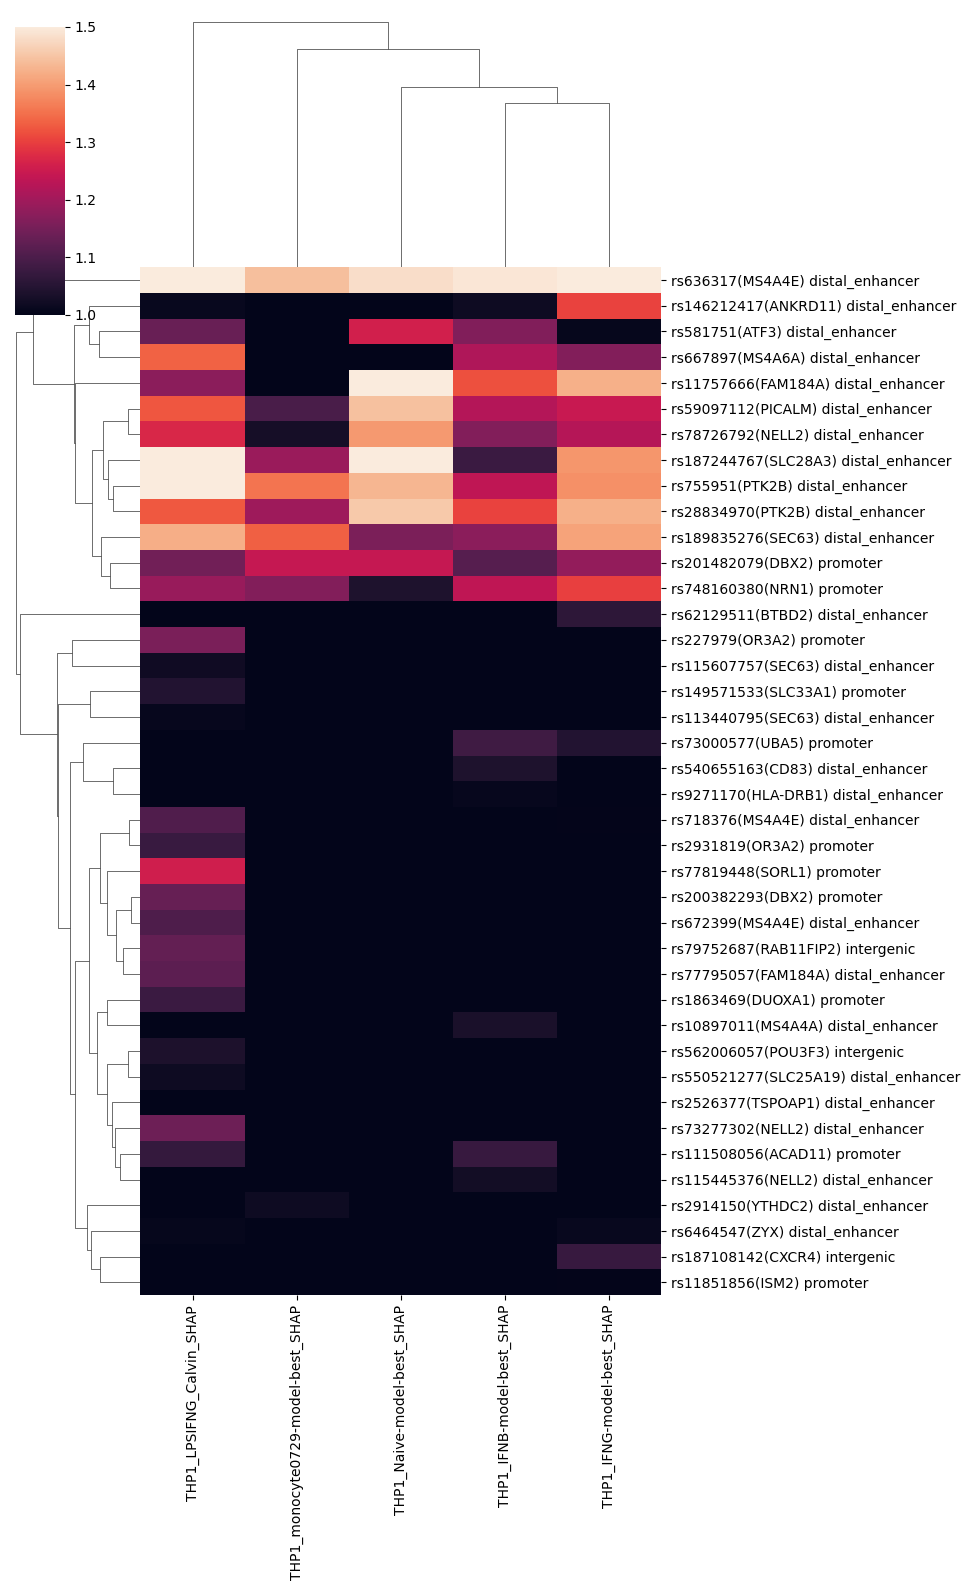

In [23]:
thp1lpsifng_rows_sorted = sort_rows_by_sum(all_p_values_unique[ (all_p_values_unique['THP1_Naive-model-best_SHAP'] > p_threshold) & (all_p_values_unique['THP1_LPSIFNG_Calvin_SHAP'] <= p_threshold)],'THP1_LPSIFNG')
thp1ifng_rows_sorted = sort_rows_by_sum(all_p_values_unique[ (all_p_values_unique['THP1_Naive-model-best_SHAP'] > p_threshold) & (all_p_values_unique['THP1_IFNG-model-best_SHAP'] <= p_threshold)],'THP1_IFNG')
thp1ifnb_rows_sorted = sort_rows_by_sum(all_p_values_unique[ (all_p_values_unique['THP1_Naive-model-best_SHAP'] > p_threshold) & (all_p_values_unique['THP1_IFNB-model-best_SHAP'] <= p_threshold)],'THP1_IFNB')
# Find rows where THP1_monocyte0729-model-best_SHAP meets the threshold, but all other THP1 columns don't
mask = (all_p_values_unique['THP1_monocyte0729-model-best_SHAP'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)
thp1_mono_rows = all_p_values_unique[mask]
thp1_mono_rows_sorted = sort_rows_by_sum(thp1_mono_rows, 'THP1_monocyte0729')

# Concatenate all sorted DataFrames
df_sorted_visualize = pd.concat([
    thp1_mono_rows_sorted ,thp1_rows_sorted,thp1lpsifng_rows_sorted,thp1ifng_rows_sorted,thp1ifnb_rows_sorted,
]).drop_duplicates()

# Drop unwanted columns safely
columns_to_keep = [col for col in all_p_values_unique.columns if 'THP1' in col]
df_sorted_visualize = df_sorted_visualize[columns_to_keep]
g = sns.clustermap(
    -np.log10(df_sorted_visualize),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 16),col_cluster=True,row_cluster=True
)
g.ax_heatmap.set_ylabel("")

In [ ]:
import numpy as np
import pandas as pd

def compute_shap_pvalues_empirical(
    npz_file_path_major_minor: str,
    npz_file_path_major_minor_null: str,
    index_csv_path: str,
    distance: int = 0
) -> pd.DataFrame:
    """
    Compute empirical p-values for SHAP effect sizes.

    Parameters
    ----------
    npz_file_path_major_minor : str
        Path to the first .npz file (major/minor).
    npz_file_path_major_minor_null : str
        Path to the second .npz file (major/minor) for the null distribution.
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.
    distance : int, optional
        Flanking distance around position 250 (default=0 => only position 250).

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    def split_shap(shap_scores_squeezed, distance=0):
        """Splits SHAP values into left, SNP, and right based on distance."""
        if distance != 0:
            left = shap_scores_squeezed[:, :, (250 - distance):250]
            snp = shap_scores_squeezed[:, :, 250]
            right = shap_scores_squeezed[:, :, 251:(251 + distance)]
            return left, snp, right
        else:
            snp = shap_scores_squeezed[:, :, 250]
            return None, snp, None

    # ----------------------------------------
    # 1. Load SHAP arrays
    # ----------------------------------------
    shap_data_1 = np.load(npz_file_path_major_minor)
    shap_data_2 = np.load(npz_file_path_major_minor_null)

    shap_scores_squeezed_1 = np.squeeze(shap_data_1['arr_0'])
    shap_scores_squeezed_2 = np.squeeze(shap_data_2['arr_0'])

    # Number of SNPs
    N = 855

    # Extract major/minor SHAP values
    shap_scores_major_1 = shap_scores_squeezed_1[:N, :, :]
    shap_scores_minor_1 = shap_scores_squeezed_1[N:, :, :]
    shap_scores_major_2 = shap_scores_squeezed_2[:N, :, :]
    shap_scores_minor_2 = shap_scores_squeezed_2[N:, :, :]

    # ----------------------------------------
    # 2. Compute SHAP Differences
    # ----------------------------------------
    left_major, snp_major, right_major = split_shap(shap_scores_major_1, distance)
    left_minor, snp_minor, right_minor = split_shap(shap_scores_minor_1, distance)

    left_major_null, snp_major_null, right_major_null = split_shap(shap_scores_major_2, distance)
    left_minor_null, snp_minor_null, right_minor_null = split_shap(shap_scores_minor_2, distance)

    if left_major is not None:
        left_diff = np.sum(left_major - left_minor, axis=1)
        right_diff = np.sum(right_major - right_minor, axis=1)
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = np.concatenate((left_diff, snp_diff, right_diff), axis=1)
        
        left_diff_null = np.sum(left_major_null - left_minor_null, axis=1)
        right_diff_null = np.sum(right_major_null - right_minor_null, axis=1)
        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = np.concatenate((left_diff_null, snp_diff_null, right_diff_null), axis=1)
    else:
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = snp_diff

        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = snp_diff_null

    # ----------------------------------------
    # 3. Normalize & Compute Summed Values
    # ----------------------------------------
    divisor = (distance * 2 + 1) if distance != 0 else 1
    sliced_array = shap_scores_diff / divisor
    sliced_array_null = shap_scores_diff_null / divisor

    summed_values = np.sum(np.abs(sliced_array), axis=1)
    summed_values_null = np.sum(np.abs(sliced_array_null), axis=1)

    # ----------------------------------------
    # 4. Replace Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # 5. Compute Empirical P-values
    # ----------------------------------------
    pvals = np.mean(summed_values_null >= summed_values[:, None], axis=1)

    # ----------------------------------------
    # 6. Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[EMPIRICAL P-VALUES COMPUTED] Total SNPs: {N}")

    return df_result

folders = ['H1_IFNB-model-best_SHAP',                     'THP1_IFNB-model-best_SHAP',
'H1_resting-model-best_SHAP',                  'THP1_IFNG-model-best_SHAP',
'HEK293_ATAC_high_depth0729-model-best_SHAP',  'THP1_LPSIFNG_Calvin_SHAP',
'HEK293T_ATAC-model-best_SHAP',                'THP1_monocyte0729-model-best_SHAP',
'Mouse_Cortex_AgeB-model-best_SHAP',           'THP1_Naive-model-best_SHAP',
'Mouse_Cortex_AgeC-model-best_SHAP',           'WTC11_IFNB-model-best_SHAP',
'Mouse_Striatum_AgeB-model-best_SHAP',         'WTC11_resting-model-best_SHAP',
'Mouse_Striatum_AgeC-model-best_SHAP',
]
pairs = []
for f in folders:
    pairs.append((
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/{f}/attributions_from_shap.npz',
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/{f}/attributions_from_shap.npz',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
for (file1, file2,model) in pairs:
    df_result = compute_shap_pvalues_no_fdr(
        npz_file_path_major_minor=file1,
        npz_file_path_major_minor_null=file2,
        index_csv_path=index_csv_path,
        distance=0  # or use something else
    )
    # you can store or save df_result
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']

df_index = pd.read_csv('../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]

p_threshold = 0.01

# Select columns that contain 'THP1'
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
thp1_columns.remove('THP1_monocyte0729-model-best_SHAP')
# Find rows where all selected columns have values <= 0.05
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
wtc11_columns = [col for col in all_p_values_unique.columns if 'WTC11' in col]
# Find rows where all selected columns have values <= 0.05
wtc11_rows = all_p_values_unique[(all_p_values_unique[wtc11_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_cortex_columns = [col for col in all_p_values_unique.columns if 'Mouse_Cortex' in col]
# Find rows where all selected columns have values <= 0.05
mouse_cortex_rows = all_p_values_unique[(all_p_values_unique[mouse_cortex_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_striatum_columns = [col for col in all_p_values_unique.columns if 'Mouse_Striatum' in col]
# Find rows where all selected columns have values <= 0.05
mouse_striatum_rows = all_p_values_unique[(all_p_values_unique[mouse_striatum_columns] <= p_threshold).all(axis=1)]
df_visualize = pd.concat([thp1_rows,mouse_striatum_rows,mouse_striatum_rows] ).drop_duplicates().drop(['H1_IFNB-model-best_SHAP', 'H1_resting-model-best_SHAP','WTC11_IFNB-model-best_SHAP','WTC11_resting-model-best_SHAP','THP1_monocyte0729-model-best_SHAP'],axis=1)



[LOGNORMAL FIT] shape=2.0746, loc=0.0000, scale=0.0693
Total data points: 855
[LOGNORMAL FIT] shape=2.3182, loc=0.0000, scale=0.0583
Total data points: 855
[LOGNORMAL FIT] shape=2.2306, loc=0.0000, scale=0.0584
Total data points: 855
[LOGNORMAL FIT] shape=2.2160, loc=0.0000, scale=0.0596
Total data points: 855
[LOGNORMAL FIT] shape=2.1206, loc=0.0000, scale=0.0259
Total data points: 855
[LOGNORMAL FIT] shape=2.2069, loc=0.0000, scale=0.0475
Total data points: 855
[LOGNORMAL FIT] shape=2.1509, loc=0.0000, scale=0.0827
Total data points: 855
[LOGNORMAL FIT] shape=2.2812, loc=0.0000, scale=0.0763
Total data points: 855
[LOGNORMAL FIT] shape=2.4642, loc=0.0000, scale=0.0411
Total data points: 855
[LOGNORMAL FIT] shape=2.1424, loc=0.0000, scale=0.0544
Total data points: 855
[LOGNORMAL FIT] shape=2.3843, loc=0.0000, scale=0.0463
Total data points: 855
[LOGNORMAL FIT] shape=2.1973, loc=0.0000, scale=0.0552
Total data points: 855
[LOGNORMAL FIT] shape=2.2298, loc=0.0000, scale=0.0540
Total dat

# Predicted value one value

In [ ]:
import pandas as pd
df_pred = pd.read_csv('prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/THP1_LPSIFNG-Calvin_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',header=None)
group_index = df_pred.index // 2

# Group by the new index and calculate the mean
df_avg = df_pred.groupby(group_index).mean()

pred_major = df_avg.iloc[0:855]
pred_minor = df_avg.iloc[855:]
pred_minor.index = pred_major.index
pred_diff = pred_major-pred_minor

# Bayesian prediction

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ranksums

# Define the path where files are stored
path = "prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/"

# Initialize DataFrames to store statistics and p-values
df_statistic = pd.DataFrame()
df_pvalue = pd.DataFrame()

# Iterate over files in the directory
for f in os.listdir(path):
    if f.endswith('_bayesian.csv'):
        file_path = os.path.join(path, f)

        # Read the tab-separated file
        df = pd.read_csv(file_path, header=None, sep='\t')

        # Split into major and minor allele datasets
        df_major = df.iloc[0:855*2]  # First half
        df_minor = df.iloc[855*2:]  # Second half

        # Reshape into 855 rows with (64*2) columns
        df_major_reshaped = df_major.values.reshape(855, 128)  # 64 * 2 = 128
        df_minor_reshaped = df_minor.values.reshape(855, 128)

        # Compute rank-sum test for all rows efficiently using list comprehension
        stats_pvalues = [ranksums(row_minor, row_major, alternative='two-sided') for row_major, row_minor in zip(df_major_reshaped, df_minor_reshaped)]
        
        # Extract statistics and p-values
        stats_array = np.array([x.statistic for x in stats_pvalues])
        p_values_array = np.array([x.pvalue for x in stats_pvalues])

        # Use cleaned filename (without extension) for column naming
        file_prefix = os.path.splitext(f)[0][0:15]

        # Store results in DataFrames
        df_statistic[file_prefix] = stats_array
        df_pvalue[file_prefix] = p_values_array

    # Save results as CSV files
    #df_statistic.to_csv(os.path.join(path, "ranksum_statistics.csv"), index=False)
    #df_pvalue.to_csv(os.path.join(path, "ranksum_p_values.csv"), index=False)

print("Rank-sum test completed and results saved.")


Rank-sum test completed and results saved.


# Comparison

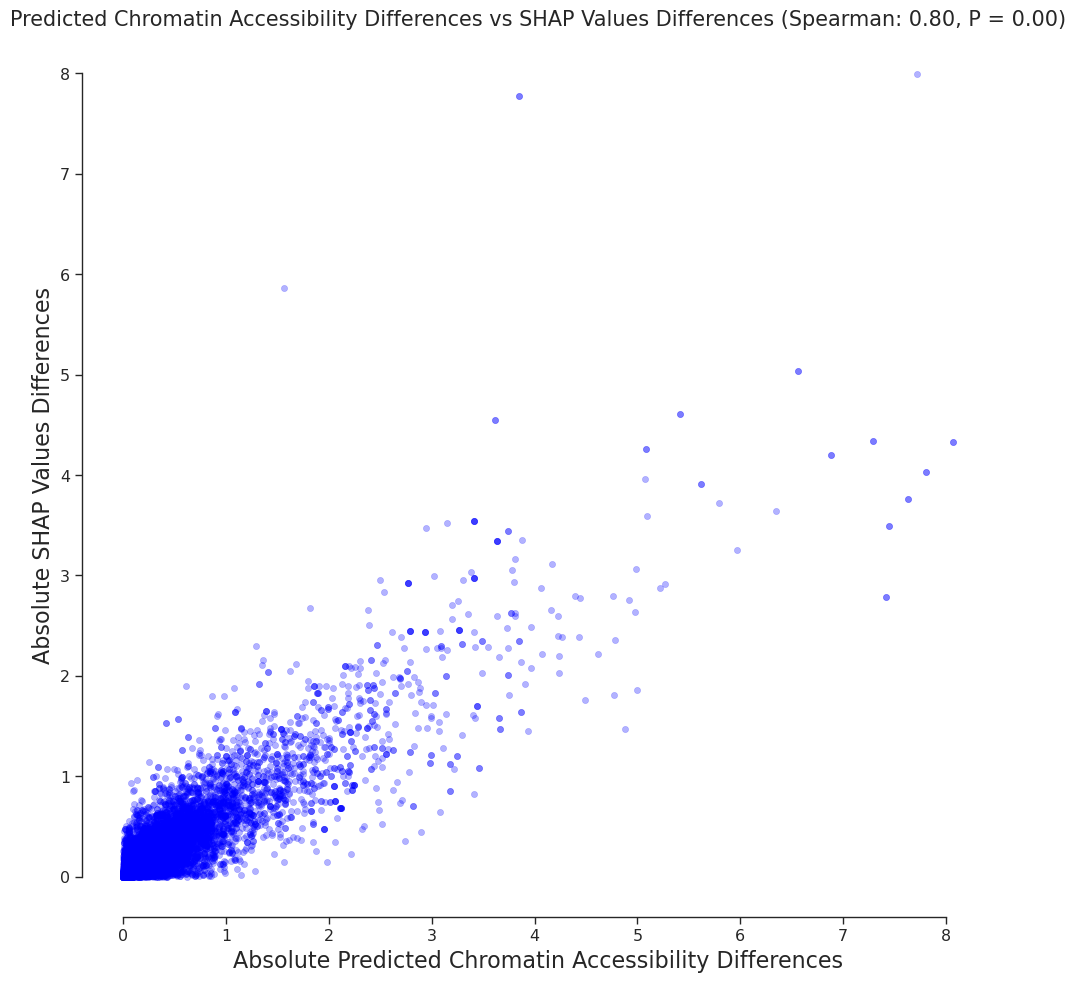

In [ ]:
import os
import numpy as np
import pandas as pd

# Set the base directory
base_folder = '../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/'

# Get all subfolders in the base directory
folder_names = [d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))]

# Dictionary to store summed_values for each folder
summed_values_dict = {}

# Iterate over each folder
for folder in folder_names:
    folder_path = os.path.join(base_folder, folder)
    
    # Define the file paths for the NPZ files
    npz_file_path = os.path.join(folder_path, 'attributions_from_shap.npz')
    seq_file_path = os.path.join(folder_path, 'onehot_encoded_sequences.npz')
    
    # Check if both files exist
    if not (os.path.exists(npz_file_path) and os.path.exists(seq_file_path)):
        print(f"Skipping {folder_path}: required files not found.")
        continue
    
    try:
        # Load NPZ files
        seq_data  = np.load(seq_file_path)
        shap_data = np.load(npz_file_path)
    except Exception as e:
        print(f"Error loading files in {folder_path}: {e}")
        continue
    
    # Convert NPZ arrays to numpy arrays
    shap_scores_raw = np.array(shap_data['arr_0'])
    seq_data_raw = np.array(seq_data['arr_0'])
    
    # Remove extra dimensions if necessary
    shap_scores_squeezed = np.squeeze(shap_scores_raw)
    
    # Split into 'major' and 'minor' parts.
    # Here, 855 is used as the cutoff; adjust if needed.
    shap_scores_major = shap_scores_squeezed[:855, :, :]
    shap_scores_minor = shap_scores_squeezed[855:, :, :]
    
    # Split SHAP scores into segments using the externally defined split_shap function.
    # (Make sure 'split_shap' and 'distance' are defined in your code.)
    left_major, snp_major, right_major = split_shap(shap_scores_major, distance=distance)
    left_minor, snp_minor, right_minor = split_shap(shap_scores_minor, distance=distance)
    
    # Compute the difference between major and minor predictions.
    if left_major is not None:
        left_difference = np.sum((left_major - left_minor), axis=1)
        right_difference = np.sum((right_major - right_minor), axis=1)
        snp_difference = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(855, 1)
        shap_scores_diff2 = np.concatenate((left_difference, snp_difference, right_difference), axis=1)
    else:
        snp_difference = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(855, 1)
        shap_scores_diff2 = snp_difference
    
    # Normalize by the window size (distance*2+1)
    sliced_array = shap_scores_diff2 / (distance * 2 + 1)
    
    # Calculate summed absolute SHAP values for each example (row)
    summed_values = np.sum(np.abs(sliced_array), axis=1)
    
    # Store the result in the dictionary using the folder name as key
    summed_values_dict[folder] = summed_values

# Create a DataFrame from the dictionary.
# Each column corresponds to one folder.
df_summed_values = pd.DataFrame(summed_values_dict)

########################################################################################
import os
import glob
import pandas as pd

# Define the folder containing the CSV files
folder = 'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/'

# Get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(folder, '*one.csv'))

# Create a dictionary to store pred_diff from each file
pred_diff_dict = {}

for file in csv_files:
    # Read the CSV file; header=None as in your snippet
    df_pred = pd.read_csv(file, header=None)
    
    # Group the rows in pairs and compute the mean
    group_index = df_pred.index // 2
    df_avg = df_pred.groupby(group_index).mean()
    
    # Split the averaged dataframe into 'major' and 'minor' predictions.
    # Adjust the slicing (0:855 and 855:) if the number of rows changes between files.
    pred_major = df_avg.iloc[0:855]
    pred_minor = df_avg.iloc[855:]
    pred_minor.index = pred_major.index  # Ensure the indices match
    
    # Compute the difference
    pred_diff = pred_major - pred_minor
    
    # Use the base filename (without folder path) as a key
    key = os.path.basename(file)
    pred_diff_dict[key] = pred_diff[0]

# Combine all pred_diff dataframes into one.
# Here we concatenate along columns. The resulting dataframe will have a MultiIndex
# for columns: the first level is the file name and the second level is the original column.
df_all_pred_diff = pd.concat(pred_diff_dict, axis=1)

df_summed_values = df_summed_values.sort_index(axis=1)
df_all_pred_diff = df_all_pred_diff.sort_index(axis=1)
df_all_pred_diff.columns = df_summed_values.columns
df_all_pred_diff = df_all_pred_diff.drop(['THP1_LPSIFNGvsIFNG-model-best_SHAP','THP1_LPSIFNGvsNaive-model-best_SHAP'],axis=1)
df_summed_values = df_summed_values.drop(['THP1_LPSIFNGvsIFNG-model-best_SHAP','THP1_LPSIFNGvsNaive-model-best_SHAP'],axis=1)
df_shap_long = df_summed_values.melt(var_name='Folder', value_name='Summed_Value')
df_diff_long = df_all_pred_diff.melt(var_name='Folder', value_name='Summed_Value')

#############################################################################################

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Set publication-style context and style
sns.set_context("paper", font_scale=1.3)
sns.set_style("ticks")

# Prepare your data
abs_df_shap_long = abs(df_shap_long['Summed_Value'])
abs_df_diff_long = abs(df_diff_long['Summed_Value'])

# Set up the figure with a larger size for clarity
fig, ax = plt.subplots(figsize=(10, 10))

# Create a scatter plot with enhanced marker properties
sns.scatterplot(x=abs_df_diff_long, y=abs_df_shap_long,
                ax=ax, alpha=0.3, s=20, color="blue", edgecolor=None)

# Calculate the Spearman correlation
correlation, p = spearmanr(abs_df_diff_long, abs_df_shap_long)

# Format the plot with larger fonts for publication
ax.set_xlabel("Absolute Predicted Chromatin Accessibility Differences", fontsize=16)
ax.set_ylabel("Absolute SHAP Values Differences", fontsize=16)
ax.set_title(f"Predicted Chromatin Accessibility Differences vs SHAP Values Differences (Spearman: {correlation:.2f}, P = {p:.2f})", fontsize=15)

# Remove the top and right spines for a cleaner look
sns.despine(trim=True)

# Optimize layout
plt.tight_layout()
plt.savefig('SHAP_VS_Diff.pdf',dpi=300)
plt.show()


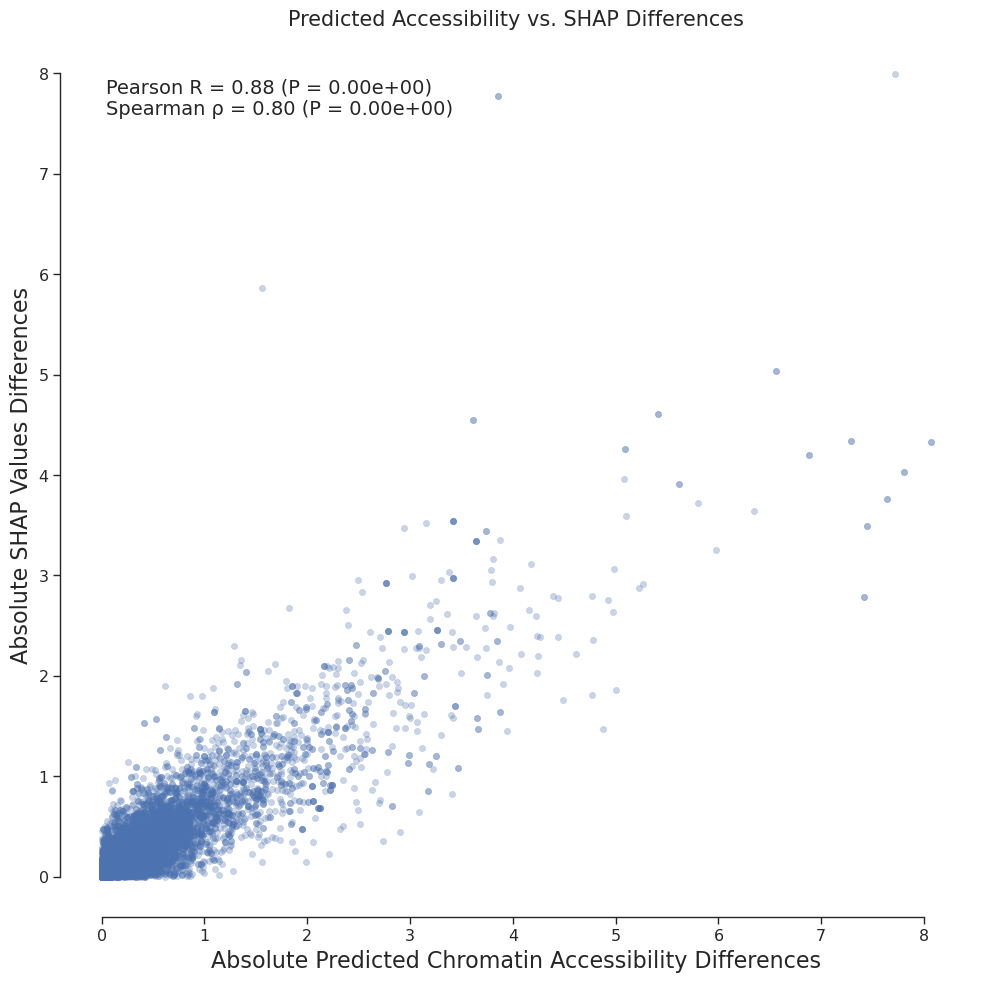

In [235]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# ──────────────────────────────────────────────────────────────
# (Assume df_shap_long and df_diff_long are already prepared)
# ──────────────────────────────────────────────────────────────
abs_shap = df_shap_long['Summed_Value'].abs()
abs_diff = df_diff_long['Summed_Value'].abs()

# ──────────────────────────────────────────────────────────────
# Compute correlations
# ──────────────────────────────────────────────────────────────
pearson_r, pearson_p = pearsonr(abs_diff, abs_shap)
spearman_rho, spearman_p = spearmanr(abs_diff, abs_shap)

# ──────────────────────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────────────────────
sns.set_context("paper", font_scale=1.3)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(
    x=abs_diff,
    y=abs_shap,
    ax=ax,
    alpha=0.3,
    s=20,
    edgecolor=None
)

# Build annotation text
annot = (
    f"Pearson R = {pearson_r:.2f} (P = {pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_rho:.2f} (P = {spearman_p:.2e})"
)

ax.text(
    0.05, 0.95, annot,
    transform=ax.transAxes,
    fontsize=14,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

ax.set_xlabel("Absolute Predicted Chromatin Accessibility Differences", fontsize=16)
ax.set_ylabel("Absolute SHAP Values Differences", fontsize=16)
ax.set_title("Predicted Accessibility vs. SHAP Differences", fontsize=15)
sns.despine(trim=True)
plt.tight_layout()

plt.savefig('SHAP_VS_Diff.pdf', dpi=300)
plt.show()


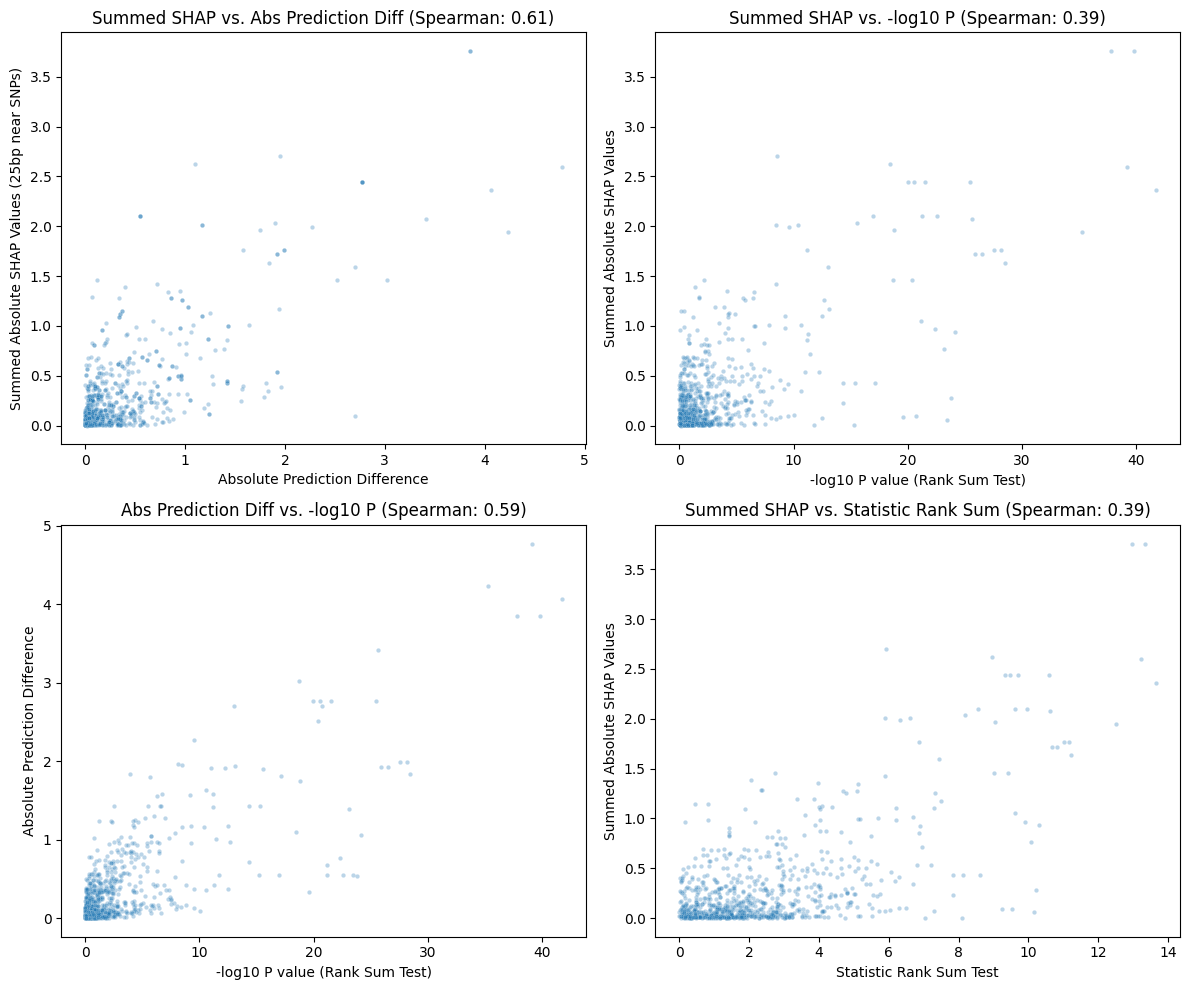

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Assuming pred_diff, summed_values, df_pvalue, and df_statistic are defined
abs_pred_diff = np.abs(pred_diff[0])  # Take absolute values of pred_diff
log_p_value = -np.log10(df_pvalue['THP1_LPSIFNG-Ca'])
abs_statistic = np.abs(df_statistic['THP1_LPSIFNG-Ca'])

# Set up figure with four subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Absolute Prediction Difference vs Summed Absolute SHAP Values
sns.scatterplot(x=abs_pred_diff, y=summed_values, ax=axes[0, 0], alpha=0.3, s=10)
correlation, _ = spearmanr(abs_pred_diff, summed_values)
axes[0, 0].set_xlabel("Absolute Prediction Difference")
axes[0, 0].set_ylabel("Summed Absolute SHAP Values (25bp near SNPs)")
axes[0, 0].set_title(f"Summed SHAP vs. Abs Prediction Diff (Spearman: {correlation:.2f})")

# Subplot 2: -log10 P value vs Summed Absolute SHAP Values
sns.scatterplot(x=log_p_value, y=summed_values, ax=axes[0, 1], alpha=0.3, s=10)
correlation, _ = spearmanr(log_p_value, summed_values)
axes[0, 1].set_xlabel("-log10 P value (Rank Sum Test)")
axes[0, 1].set_ylabel("Summed Absolute SHAP Values")
axes[0, 1].set_title(f"Summed SHAP vs. -log10 P (Spearman: {correlation:.2f})")

# Subplot 3: -log10 P value vs Absolute Prediction Difference
sns.scatterplot(x=log_p_value, y=abs_pred_diff, ax=axes[1, 0], alpha=0.3, s=10)
correlation, _ = spearmanr(log_p_value, abs_pred_diff)
axes[1, 0].set_xlabel("-log10 P value (Rank Sum Test)")
axes[1, 0].set_ylabel("Absolute Prediction Difference")
axes[1, 0].set_title(f"Abs Prediction Diff vs. -log10 P (Spearman: {correlation:.2f})")

# Subplot 4: Statistic Rank Sum Test vs Summed Absolute SHAP Values
sns.scatterplot(x=abs_statistic, y=summed_values, ax=axes[1, 1], alpha=0.3, s=10)
correlation, _ = spearmanr(abs_statistic, summed_values)
axes[1, 1].set_xlabel("Statistic Rank Sum Test")
axes[1, 1].set_ylabel("Summed Absolute SHAP Values")
axes[1, 1].set_title(f"Summed SHAP vs. Statistic Rank Sum (Spearman: {correlation:.2f})")

# Adjust layout
plt.tight_layout()
plt.show()



# Deterministic negative background

In [ ]:
import pandas as pd
import os
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import numpy as np
from tqdm import tqdm

def calculate_gc_content(sequence):
    return (sequence.count("G") + sequence.count("C")) / len(sequence) * 100 if sequence else 0

def match_sequences_by_gc(mpra_file, fasta_file, output_fasta):
    # Load sequence data with GC content
    df = pd.read_csv(mpra_file, index_col=0)
    df["GC_Content"] = df["Sequence_Major_padded"].apply(calculate_gc_content)

    # Load and compute GC content for FASTA sequences
    fasta_sequences = [
        {
            "ID": record.id,
            "Sequence": str(record.seq),
            "GC_Content": calculate_gc_content(str(record.seq))
        }
        for record in SeqIO.parse(fasta_file, "fasta")
    ]

    # Sort by GC content and reset index
    fasta_df = pd.DataFrame(fasta_sequences).sort_values(by="GC_Content").reset_index(drop=True)
    gc_values = fasta_df["GC_Content"].values  # Sorted GC content

    used_ids = set()
    matched_sequences = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Matching sequences"):
        target_gc = row["GC_Content"]
        target_base_250_major = row["Sequence_Major_padded"][250]
        target_base_250_minor = row["Sequence_Minor_padded"][250]

        # 1) Try to find a match via the three closest GC indices from binary search
        idx = np.searchsorted(gc_values, target_gc)
        candidate_indices = np.clip([idx - 1, idx, idx + 1], 0, len(fasta_df) - 1)

        found_match = None
        for i in candidate_indices:
            potential = fasta_df.iloc[i]
            # Check if unused and matches the 250th base
            if (
                potential["ID"] not in used_ids
                and potential["Sequence"][250] == target_base_250_major
            ):
                found_match = potential
                used_ids.add(found_match["ID"])
                break

        # 2) If still not found, expand GC range in 0.5% increments up to ±5%
        range_step = 0.5
        max_range = 5.0
        while found_match is None and range_step <= max_range:
            lower_bound = target_gc - range_step
            upper_bound = target_gc + range_step

            # Filter by relaxed GC range and unused IDs
            subset = fasta_df[
                (fasta_df["GC_Content"] >= lower_bound)
                & (fasta_df["GC_Content"] <= upper_bound)
                & (~fasta_df["ID"].isin(used_ids))
            ]

            # Check for matching base
            matching_rows = subset[subset["Sequence"].str[250] == target_base_250_major]
            if not matching_rows.empty:
                found_match = matching_rows.iloc[0]
                used_ids.add(found_match["ID"])
            else:
                range_step += 0.5

        # 3) If a match is found, record the details
        if found_match is not None:
            matched_sequences.append({
                "Original_Sequence": row["Sequence_Major_padded"],
                "Original_GC": target_gc,
                "Matched_Sequence_OriginalAllele": found_match["Sequence"],
                "Matched_Sequence_SyntheticMinorAllele": (
                    found_match["Sequence"][:250]
                    + target_base_250_minor
                    + found_match["Sequence"][251:]
                ),
                "Matched_GC": found_match["GC_Content"],
                "Matched_ID": found_match["ID"]
            })

    # Convert results to DataFrame
    matched_df = pd.DataFrame(matched_sequences)

    # Report how many matches were found
    total_sequences = len(df)
    matched_count = len(matched_df)
    print(f"Number of matched sequences: {matched_count} out of {total_sequences}")

    # Save matched sequences to FASTA if any matches found
    if matched_count > 0:
        fasta_records = []
        for _, row in matched_df.iterrows():
            for col in ["Matched_Sequence_OriginalAllele"]:
                seq_str = row[col]
                record_id = f"{row['Matched_ID']}_{col.split('_')[-1]}_{seq_str[250]}_GC{int(row['Matched_GC'])}"
                fasta_records.append(SeqRecord(Seq(seq_str), id=record_id, description=""))
        for _, row in matched_df.iterrows():
            for col in ["Matched_Sequence_SyntheticMinorAllele"]:
                seq_str = row[col]
                record_id = f"{row['Matched_ID']}_{col.split('_')[-1]}_{seq_str[250]}_GC{int(row['Matched_GC'])}"
                fasta_records.append(SeqRecord(Seq(seq_str), id=record_id, description=""))
        SeqIO.write(fasta_records, output_fasta, "fasta")
        print(f"FASTA file saved as {output_fasta}")
    else:
        print("No sequences were matched. No FASTA file generated.")

def process_all_fasta(end_keywords, mpra_file, fasta_dir,output_dir,):
    for fasta_file in os.listdir(fasta_dir):
        if fasta_file.endswith(end_keywords):
            fasta_path = os.path.join(fasta_dir, fasta_file)
            output_name = fasta_file.split(".")[0] + "_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta"
            output_path = os.path.join(output_dir, output_name)
            match_sequences_by_gc(mpra_file, fasta_path, output_path)

# Example usage
process_all_fasta(
    end_keywords = "GCmatch_background_noOverlap_validation.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "GCmatch_background_noOverlap_validation.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_mm10",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)

Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1342.17it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_IFNG_4hrs_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1418.12it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_4hrs_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1566.79it/s]


...

Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_IFNG_neg_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1291.69it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_Naive_pos_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1210.64it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_IFNG_pos_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


# Random background

In [ ]:
import pandas as pd
import os
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import numpy as np
from tqdm import tqdm

def calculate_gc_content(sequence):
    return (sequence.count("G") + sequence.count("C")) / len(sequence) * 100 if sequence else 0

def match_sequences_by_gc(mpra_file, fasta_file, output_fasta):
    # Load sequence data with GC content
    df = pd.read_csv(mpra_file, index_col=0)
    df["GC_Content"] = df["Sequence_Major_padded"].apply(calculate_gc_content)

    # Load and compute GC content for FASTA sequences
    fasta_sequences = [
        {
            "ID": record.id,
            "Sequence": str(record.seq),
            "GC_Content": calculate_gc_content(str(record.seq))
        }
        for record in SeqIO.parse(fasta_file, "fasta")
    ]

    # Sort by GC content and reset index
    fasta_df = pd.DataFrame(fasta_sequences).sort_values(by="GC_Content").reset_index(drop=True)
    gc_values = fasta_df["GC_Content"].values  # Sorted GC content

    used_ids = set()
    matched_sequences = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Matching sequences"):
        target_gc = row["GC_Content"]
        target_base_250_major = row["Sequence_Major_padded"][250]
        target_base_250_minor = row["Sequence_Minor_padded"][250]

        found_match = None

        # 1) Try to find a match via the three closest GC indices from binary search
        idx = np.searchsorted(gc_values, target_gc)
        # Use unique indices in case idx-1, idx, idx+1 have duplicates
        candidate_indices = np.unique(np.clip([idx - 1, idx, idx + 1], 0, len(fasta_df) - 1))
        candidates = fasta_df.iloc[candidate_indices]
        # Filter candidates by unused IDs and matching 250th base
        candidates = candidates[
            (~candidates["ID"].isin(used_ids)) &
            (candidates["Sequence"].str[250] == target_base_250_major)
        ]
        if not candidates.empty:
            # Randomly pick one candidate from the available matches
            found_match = candidates.sample(n=1).iloc[0]
            used_ids.add(found_match["ID"])

        # 2) If still not found, expand GC range in 0.5% increments up to ±5%
        range_step = 0.5
        max_range = 5.0
        while found_match is None and range_step <= max_range:
            lower_bound = target_gc - range_step
            upper_bound = target_gc + range_step

            # Filter by relaxed GC range and unused IDs
            subset = fasta_df[
                (fasta_df["GC_Content"] >= lower_bound) &
                (fasta_df["GC_Content"] <= upper_bound) &
                (~fasta_df["ID"].isin(used_ids))
            ]

            # Check for matching base at position 250
            matching_rows = subset[subset["Sequence"].str[250] == target_base_250_major]
            if not matching_rows.empty:
                # Randomly pick one candidate from the matching rows
                found_match = matching_rows.sample(n=1).iloc[0]
                used_ids.add(found_match["ID"])
            else:
                range_step += 0.5

        # 3) If a match is found, record the details
        if found_match is not None:
            matched_sequences.append({
                "Original_Sequence": row["Sequence_Major_padded"],
                "Original_GC": target_gc,
                "Matched_Sequence_OriginalAllele": found_match["Sequence"],
                "Matched_Sequence_SyntheticMinorAllele": (
                    found_match["Sequence"][:250]
                    + target_base_250_minor
                    + found_match["Sequence"][251:]
                ),
                "Matched_GC": found_match["GC_Content"],
                "Matched_ID": found_match["ID"]
            })

    # Convert results to DataFrame
    matched_df = pd.DataFrame(matched_sequences)

    # Report how many matches were found
    total_sequences = len(df)
    matched_count = len(matched_df)
    print(f"Number of matched sequences: {matched_count} out of {total_sequences}")

    # Save matched sequences to FASTA if any matches found
    if matched_count > 0:
        fasta_records = []
        for _, row in matched_df.iterrows():
            for col in ["Matched_Sequence_OriginalAllele"]:
                seq_str = row[col]
                record_id = f"{row['Matched_ID']}_{col.split('_')[-1]}_{seq_str[250]}_GC{int(row['Matched_GC'])}"
                fasta_records.append(SeqRecord(Seq(seq_str), id=record_id, description=""))
        for _, row in matched_df.iterrows():
            for col in ["Matched_Sequence_SyntheticMinorAllele"]:
                seq_str = row[col]
                record_id = f"{row['Matched_ID']}_{col.split('_')[-1]}_{seq_str[250]}_GC{int(row['Matched_GC'])}"
                fasta_records.append(SeqRecord(Seq(seq_str), id=record_id, description=""))
        SeqIO.write(fasta_records, output_fasta, "fasta")
        print(f"FASTA file saved as {output_fasta}")
    else:
        print("No sequences were matched. No FASTA file generated.")

def process_all_fasta(end_keywords, mpra_file, fasta_dir, output_dir):
    for fasta_file in os.listdir(fasta_dir):
        if fasta_file.endswith(end_keywords):
            fasta_path = os.path.join(fasta_dir, fasta_file)
            output_name = fasta_file.split(".")[0] + "_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta"
            output_path = os.path.join(output_dir, output_name)
            match_sequences_by_gc(mpra_file, fasta_path, output_path)
# Example usage
process_all_fasta(
    end_keywords = "GCmatch_background_noOverlap_validation.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "GCmatch_background_noOverlap_validation.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_mm10",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences'
)
# Example usage
process_all_fasta(
    end_keywords = "pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta",
    mpra_file="../../mpra3_lib_analysis/indexing/MPRA_SNPCenter_500bpSequences_withManualAnnotation_500bp.csv",
    fasta_dir="../../THP1_machinelearning/background_negatives_500bp_hg38",
    output_dir = 'sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences')

Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 902.11it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_IFNG_4hrs_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 908.12it/s] 


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_4hrs_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 1001.80it/s]


...

Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_IFNG_neg_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 887.36it/s] 


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_Naive_pos_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


Matching sequences: 100%|██████████| 855/855 [00:00<00:00, 861.93it/s]


Number of matched sequences: 855 out of 855
FASTA file saved as /media/zihengc/T7/THP1_machinelearning/mpra3_prediction/sequence_for_prediction/MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched_855Sequences/THP1_LPSIFNG_vs_IFNG_pos_MPRA_Major_Minor_500bp_SNPCenter_NegativeATACBackground_NoOverlap_GCmatched.fasta


In [54]:
sliced_array = shap_scores_diff[:, :, 250:251]  # Shape (855, 4, 25)
#flattened_array = sliced_array.reshape(sliced_array.shape[0], -1)  # Shape (855, 100)
flattened_array = sliced_array.reshape(855,4)

In [64]:
df = pd.DataFrame(flattened_array)
df.index = df_index.index